In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [12]:
from machines.predictions.svr_prediction import SVR_Prediction
from machines.enums import SvrKernelEnum
from preprocesses.preprocess import Preprocess
from preprocesses.enums import TransformEnum, TypeFileEnum, StandardScaleEnum
from metrics.error_metric import ErrorMetric
from metrics.enums import MetricEnum, PlotLegends

Read the file and prepare data for SVR

In [13]:
file_csv = '../../../../../../data/phen/original/obregon_phenotypic_original_151617.csv'
print(os.getcwd())
svr = SVR_Prediction(kernel=SvrKernelEnum.LINEAR)
preprocessing =  Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.PCA,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

/phen/app/notebooks/phen/pca/phenotypic/svr


Launched SVR

In [14]:
x_train, y_train = preprocessing.get_train()
svr.training(x_train=x_train, y_train=y_train)

In [15]:
x_test, y_test = preprocessing.get_test()
y_predicted = svr.prediction(x_test=x_test)

Get metrics

In [16]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 54.46837249899282
R2 -> 0.69198370624724
MAPE -> 0.07207056993555457


{'d2_absolute_error_score': 0.43671494229145147,
 'd2_pinball_score': 0.43671494229145147,
 'd2_tweedie_score': 0.69198370624724,
 'explained_variance_score': 0.7066363221428733,
 'max_error': 179.7958132389723,
 'mean_absolute_error': 39.30462653964035,
 'mean_absolute_percentage_error': 0.07207056993555457,
 'mean_gamma_deviance': 0.009810178067891046,
 'mean_poisson_deviance': 5.231768686667723,
 'mean_squared_error': 2966.8036026890377,
 'mean_squared_log_error': 0.010399524513910248,
 'median_absolute_error': 28.492848415199035,
 'r2_score': 0.69198370624724,
 'root_mean_squared_error': 54.46837249899282,
 'root_mean_squared_log_error': 0.10197805898285302}

Plots:

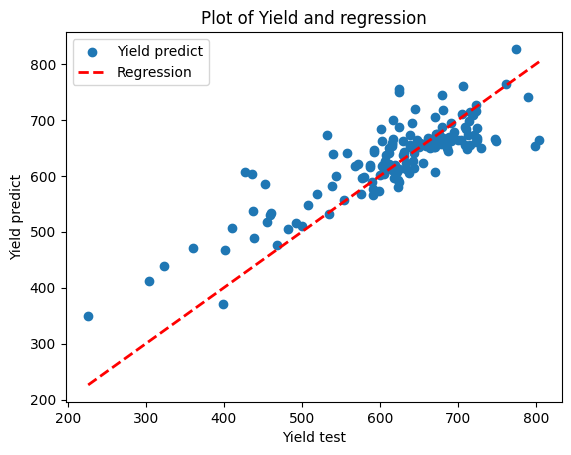

In [17]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = "Plot of Yield and regression"
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)


Plot $r^2$

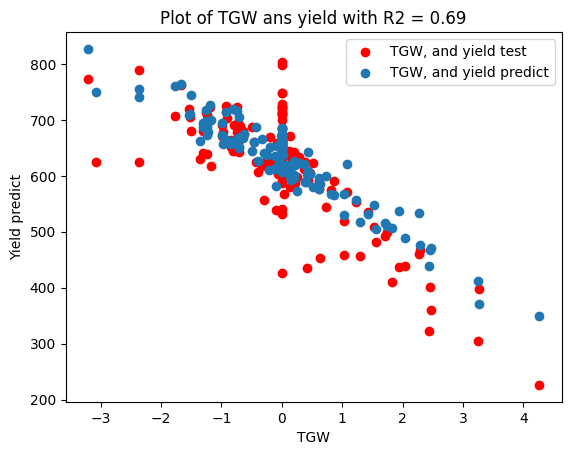

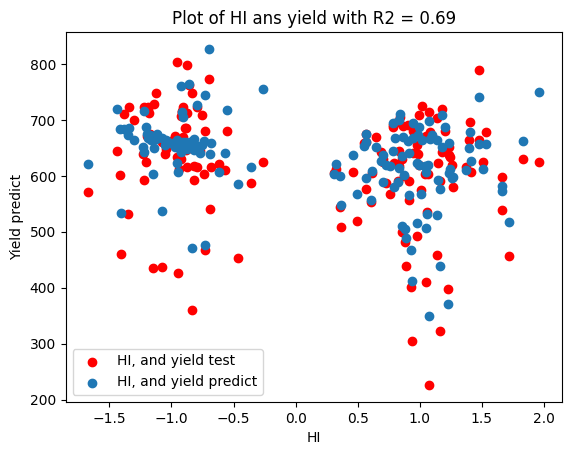

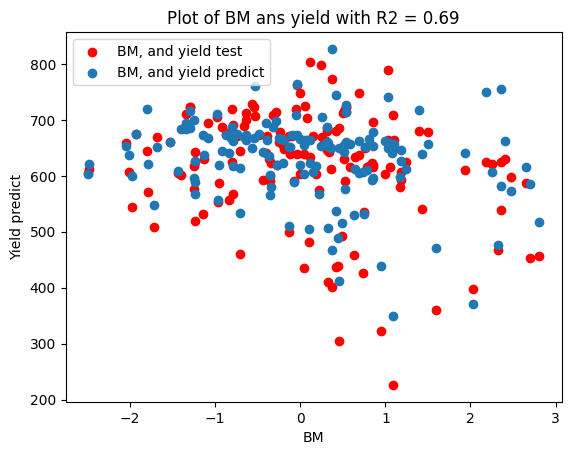

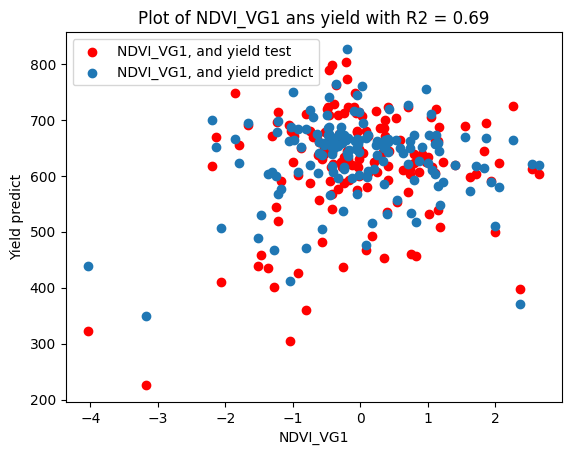

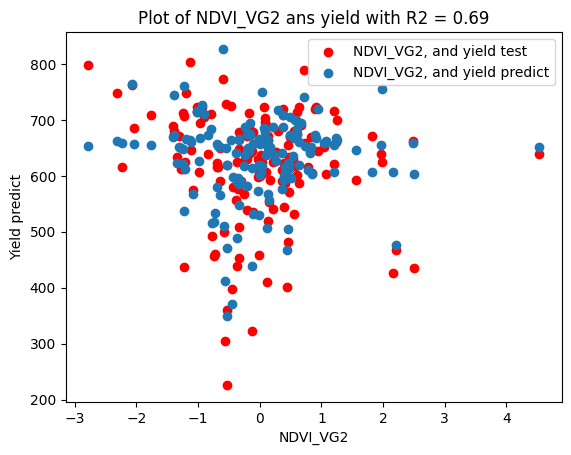

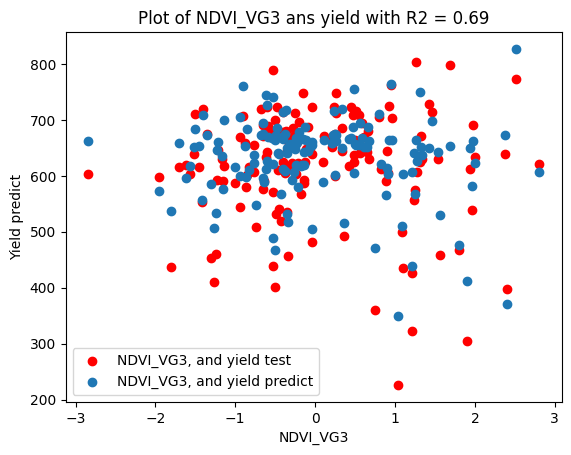

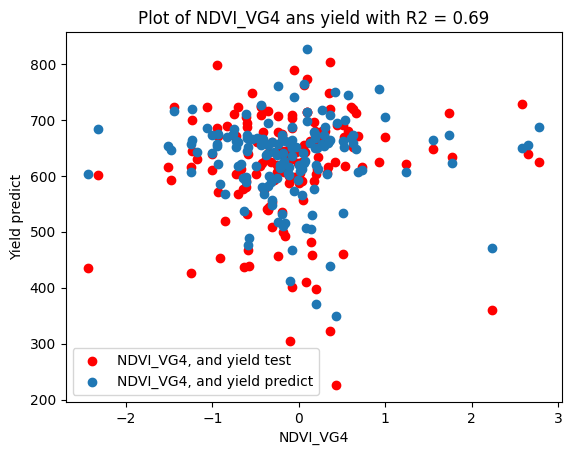

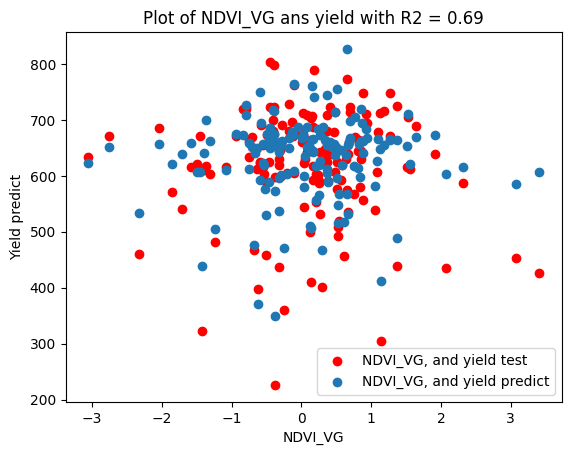

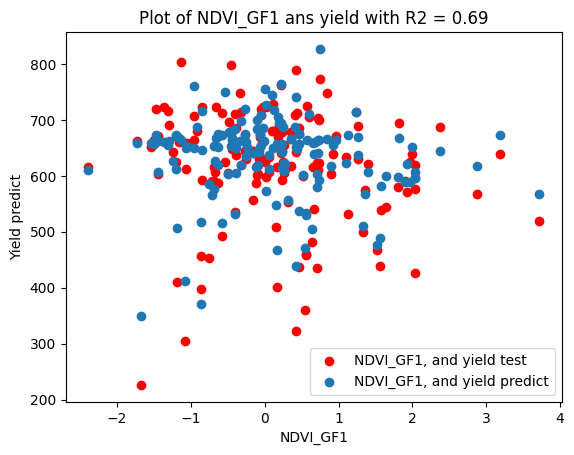

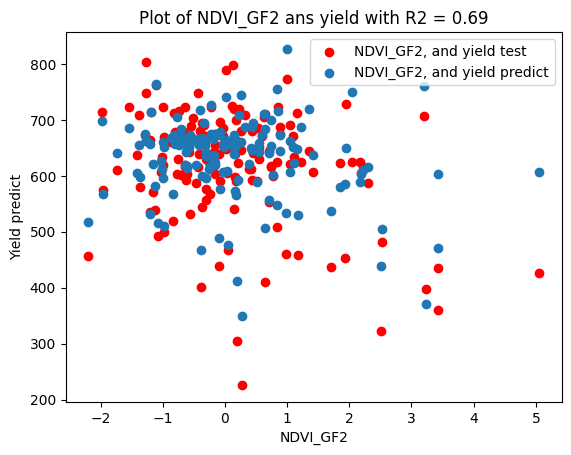

In [18]:
legend = PlotLegends()
legend.first_plot_label = "{variable}, and yield test"
legend.second_plot_label = "{variable}, and yield predict"
legend.title = "Plot of {variable} ans yield with R2 = {r2:.2f}"
legend.x_label = "{variable}"
legend.y_label = "Yield predict"
features = preprocessing.get_name_features()
metric.plot_r2_predicted(legend=legend, features=features)

Get the predict that are more bigger that .05

In [19]:
metric.list_percentage_error_upper(pivot=.04, sort = 'error')

[{'truth': 226.1118,
  'predict': 349.19884833479415,
  'error': 0.5443636658272332},
 {'truth': 427.0, 'predict': 606.7958132389723, 'error': 0.42106747831141056},
 {'truth': 436.0, 'predict': 603.6422369563923, 'error': 0.38450054347796386},
 {'truth': 322.9881,
  'predict': 438.7287006616423,
  'error': 0.35834323512736943},
 {'truth': 304.5419,
  'predict': 412.65107744510846,
  'error': 0.3549895020852909},
 {'truth': 360.0, 'predict': 470.6404167138388, 'error': 0.3073344908717745},
 {'truth': 453.0, 'predict': 585.8167590300499, 'error': 0.29319372854315645},
 {'truth': 532.0, 'predict': 673.7891538241101, 'error': 0.2665209658347935},
 {'truth': 409.865, 'predict': 507.17415949503834, 'error': 0.237417587486217},
 {'truth': 437.0, 'predict': 537.3679856162277, 'error': 0.22967502429342712},
 {'truth': 625.0, 'predict': 756.0884833358705, 'error': 0.20974157333739277},
 {'truth': 625.0229,
  'predict': 750.7288898124939,
  'error': 0.20112221458204785},
 {'truth': 540.0, 'predic